In [13]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import random
from tqdm import tqdm

In [2]:
class MobileNetV2Backbone(nn.Module):
    def __init__(self):
        super().__init__()
    
        mv2 = models.mobilenet_v2(weights="IMAGENET1K_V1")

        self.stage1 = nn.Sequential(*mv2.features[0:4])
        self.stage2 = nn.Sequential(*mv2.features[4:7])
        self.stage3 = nn.Sequential(*mv2.features[7:14])
        self.stage4 = nn.Sequential(*mv2.features[14:17])

    def forward(self, x):
        f0 = self.stage1(x)
        f1 = self.stage2(f0)
        f2 = self.stage3(f1)
        f3 = self.stage4(f2)

        return f0, f1, f2, f3
    
class FPNDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.dec0 = self._conv(24, 32)
        self.dec1 = self._conv(32, 32)
        self.dec2 = self._conv(96, 32)
        self.dec3 = self._conv(160, 32)

    def _conv(self, in_ch, out_ch):
        return nn.Sequential(
            # conv 1
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            # conv 2
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            # conv 3
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, f0, f1, f2, f3):
        d0 = self.dec0(f0)
        d1 = self.dec1(f1)
        d2 = self.dec2(f2)
        d3 = self.dec3(f3)

        return d0, d1, d2, d3

class SEModule(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excite  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, reduced),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels),
            nn.Sigmoid()
        )

    def get_weights(self, x):
        # returns [B, C, 1, 1] — broadcasts to any spatial size
        B, C, _, _ = x.shape
        w = self.excite(self.squeeze(x))
        return w.view(B, C, 1, 1)

    def forward(self, x):
        return x * self.get_weights(x)


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def get_weights(self, x):
        # returns [B, 1, H, W]
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _  = torch.max(x,  dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

    def forward(self, x):
        return x * self.get_weights(x)

class DACF(nn.Module):
    def __init__(self, channels=32):
        super().__init__()

        self.se = SEModule(channels)
        self.sa = SpatialAttention()

        # stride-1 conv to downsample wF_shallow → match deep spatial size
        self.conv_down  = nn.Conv2d(channels, channels, kernel_size=1, stride=2, bias=False)

        # 1x1 convs (DACF replaces 3x3 with 1x1 for efficiency)
        self.conv_inner = nn.Conv2d(channels * 2, channels, kernel_size=1, bias=False)
        self.conv_outer = nn.Conv2d(channels,     channels, kernel_size=1, bias=False)

    def forward(self, deep, shallow):
        """
        deep:    [B, C, H,   W  ]  coarse, semantic  (e.g. d3 at H/32)
        shallow: [B, C, H*2, W*2]  fine, structural  (e.g. d2 at H/16)
        returns: [B, C, H*2, W*2]  refined shallow
        """

        # 1. channel weights from deep → re-weight shallow
        w_ch       = self.se.get_weights(deep)                      # [B, C, 1, 1]
        wF_shallow = shallow * w_ch                                  # [B, C, H*2, W*2]

        # 2. spatial weights from shallow → downsample → re-weight deep
        w_sp       = self.sa.get_weights(shallow)                    # [B, 1, H*2, W*2]
        w_sp_down  = F.interpolate(w_sp, size=deep.shape[2:],
                                   mode='bilinear', align_corners=False)  # [B, 1, H, W]
        wF_deep    = deep * w_sp_down                                # [B, C, H, W]

        # 3. downsample wF_shallow to deep's spatial size
        wF_shallow_down = self.conv_down(wF_shallow)                 # [B, C, H, W]

        # 4. concatenate and upsample back
        Ci    = torch.cat([wF_shallow_down, wF_deep], dim=1)         # [B, 2C, H, W]
        Ci_up = F.interpolate(Ci, size=shallow.shape[2:],
                              mode='bilinear', align_corners=False)   # [B, 2C, H*2, W*2]

        # 5. fuse: equation (5) — conv_outer( conv_inner(Ci_up) + wF_shallow )
        out = self.conv_outer(self.conv_inner(Ci_up) + wF_shallow)   # [B, C, H*2, W*2]

        return out

class SegHead(nn.Module):
    def __init__(self, channels=32):
        super().__init__()
        self.conv = nn.Conv2d(channels, 1, kernel_size=3, padding=1, bias=True)

    def forward(self, x, target_h, target_w):
        x = self.conv(x)
        x = F.interpolate(x, size=(target_h, target_w),
                          mode='bilinear', align_corners=False)
        return torch.sigmoid(x)   # [B, 1, H, W]

class CPDR_S(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = MobileNetV2Backbone()
        self.decoder  = FPNDecoder()

        # DACF chain: coarse → fine
        self.dacf1 = DACF(channels=32)   # (d3, d2) → r2  at H/16
        self.dacf2 = DACF(channels=32)   # (r2, d1) → r1  at H/8

        # segmentation heads (3 outputs for deep supervision)
        self.head0 = SegHead(32)   # on d0  (H/4  — finest decoder feature)
        self.head1 = SegHead(32)   # on r1  (H/8  — DACF refined)
        self.head2 = SegHead(32)   # on r2  (H/16 — DACF refined)

    def forward(self, x):
        H, W = x.shape[2], x.shape[3]

        # 1. backbone
        f0, f1, f2, f3 = self.backbone(x)

        # 2. decoder: normalize channels to 32
        d0, d1, d2, d3 = self.decoder(f0, f1, f2, f3)

        # 3. DACF: cross-attention fusion, coarse-to-fine
        r2 = self.dacf1(deep=d3, shallow=d2)   # [B, 32, H/16, W/16]
        r1 = self.dacf2(deep=r2, shallow=d1)   # [B, 32, H/8,  W/8 ]

        # 4. segmentation heads — all upsampled to input resolution
        out0 = self.head0(d0, H, W)   # [B, 1, H, W]
        out1 = self.head1(r1, H, W)   # [B, 1, H, W]
        out2 = self.head2(r2, H, W)   # [B, 1, H, W]

        if self.training:
            return out0, out1, out2   # all 3 for deep supervision
        else:
            return out0               # finest prediction at inference

In [3]:
model = CPDR_S()
model.eval()

dummy = torch.randn(2, 3, 256, 256)

with torch.no_grad():
    out = model(dummy)

print(f"Output: {out.shape}")   # [2, 1, 256, 256]
print(f"Value range: [{out.min():.3f}, {out.max():.3f}]")  # should be (0, 1)

total = sum(p.numel() for p in model.parameters())
print(f"Total params: {total/1e6:.3f}M")   # expect ~1.5-1.7M

# also check training mode outputs
model.train()
with torch.no_grad():
    out0, out1, out2 = model(dummy)
print(f"out0: {out0.shape}, out1: {out1.shape}, out2: {out2.shape}")

Output: torch.Size([2, 1, 256, 256])
Value range: [0.478, 0.523]
Total params: 1.513M
out0: torch.Size([2, 1, 256, 256]), out1: torch.Size([2, 1, 256, 256]), out2: torch.Size([2, 1, 256, 256])


In [4]:
class DICELoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        intersection = (pred * target).sum(dim=(1, 2, 3))
        total        = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

        dice = (2 * intersection + self.eps) / (total + self.eps)   # ← added 2*
        return 1 - dice.mean()


class IoULoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        intersection = (pred * target).sum(dim=(1, 2, 3))
        union        = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - intersection

        iou = (intersection + self.eps) / (union + self.eps)
        return 1 - iou.mean()


class CPDRLoss(nn.Module):
    """Combined DICE + IoU with deep supervision across all 3 heads."""
    def __init__(self):
        super().__init__()
        self.dice = DICELoss()
        self.iou  = IoULoss()

    def _single(self, pred, target):
        return self.dice(pred, target) + self.iou(pred, target)

    def forward(self, preds, target):
        """
        preds:  tuple of (out0, out1, out2) during training
                or single tensor at inference
        target: [B, 1, H, W] binary ground truth mask
        """
        out0, out1, out2 = preds
        loss = self._single(out0, target) \
             + self._single(out1, target) \
             + self._single(out2, target)
        return loss

In [5]:
criterion = CPDRLoss()

target = torch.randint(0, 2, (2, 1, 256, 256)).float()

# perfect prediction
perfect = target.clone()
loss_perfect = criterion((perfect, perfect, perfect), target)
print(f"Perfect prediction loss: {loss_perfect.item():.4f}")  # expect ~0.0

# worst prediction (inverted)
worst = 1 - target
loss_worst = criterion((worst, worst, worst), target)
print(f"Worst prediction loss:   {loss_worst.item():.4f}")  # expect ~2.0

# random prediction
random_pred = torch.rand(2, 1, 256, 256)
loss_random = criterion((random_pred, random_pred, random_pred), target)
print(f"Random prediction loss:  {loss_random.item():.4f}")  # expect ~1.0

Perfect prediction loss: 0.0000
Worst prediction loss:   6.0000
Random prediction loss:  3.4917


In [6]:
class DUTSDataset(Dataset):
    def __init__(self, root, split='train', size=256):
        """
        root:  path to DUTS-TR folder
        split: 'train' or 'val' (DUTS has no official val, 
                we'll use a small subset for monitoring)
        size:  resize target
        """
        self.size = size

        img_dir  = os.path.join(root, 'DUTS-TR-Image')
        mask_dir = os.path.join(root, 'DUTS-TR-Mask')

        # pair filenames: image is .jpg, mask is .png, same stem
        stems = [f[:-4] for f in os.listdir(img_dir) if f.endswith('.jpg')]
        stems.sort()

        # 90/10 split for train/val monitoring
        split_idx = int(len(stems) * 0.9)
        if split == 'train':
            stems = stems[:split_idx]
        else:
            stems = stems[split_idx:]

        self.samples = [
            (os.path.join(img_dir,  s + '.jpg'),
             os.path.join(mask_dir, s + '.png'))
            for s in stems
        ]

        # image: resize + normalize with ImageNet stats
        self.img_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
        ])

        # mask: resize only (no normalize)
        self.mask_transform = transforms.Compose([
            transforms.Resize((size, size), interpolation=Image.NEAREST),
            transforms.ToTensor()
        ])

        self.split = split

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        img  = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')   # grayscale

        # apply the same random flip to both
        if self.split == 'train' and random.random() > 0.5:
            img  = img.transpose(Image.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.FLIP_LEFT_RIGHT)

        img  = self.img_transform(img)       # [3, H, W]
        mask = self.mask_transform(mask)     # [1, H, W], range [0,1]
        mask = (mask > 0.5).float()          # binarize

        return img, mask

In [7]:
dataset_train = DUTSDataset(root='../dataset/DUTS-TR', split='train')
dataset_val   = DUTSDataset(root='../dataset/DUTS-TR', split='val')

train_loader = DataLoader(
    dataset_train,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    dataset_val,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# quick batch check
imgs, masks = next(iter(train_loader))
print(f"Batch images: {imgs.shape}")    # [16, 3, 256, 256]
print(f"Batch masks:  {masks.shape}")   # [16, 1, 256, 256]

Batch images: torch.Size([16, 3, 256, 256])
Batch masks:  torch.Size([16, 1, 256, 256])


In [8]:
def make_scheduler(optimizer, warmup_epochs=5, total_epochs=40, gamma=3):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs          # linear ramp up
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return (1.0 - progress) ** gamma          # poly decay

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [11]:
import time

def train(model, train_loader, val_loader, 
          num_epochs=40, lr=1e-4, device='cuda', save_dir='checkpoints'):

    os.makedirs(save_dir, exist_ok=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = make_scheduler(optimizer, warmup_epochs=5, 
                                total_epochs=num_epochs, gamma=3)
    criterion = CPDRLoss()

    model = model.to(device)
    best_mae = float('inf')

    for epoch in range(num_epochs):
        # ── train phase ──────────────────────────────────────────
        model.train()
        train_loss = 0.0
        t0 = time.time()

        for imgs, masks in tqdm(train_loader, desc="Train"):
            imgs  = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)              # returns (out0, out1, out2)
            loss  = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ── val phase ────────────────────────────────────────────
        model.eval()
        mae = 0.0

        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, leave=False, desc="Validation"):
                imgs  = imgs.to(device)
                masks = masks.to(device)

                pred = model(imgs)           # single tensor at eval
                mae += (pred - masks).abs().mean().item()

        mae /= len(val_loader)

        # ── scheduler step ───────────────────────────────────────
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # ── logging ──────────────────────────────────────────────
        elapsed = time.time() - t0
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"loss: {train_loss:.4f}  "
              f"MAE: {mae:.4f}  "
              f"lr: {current_lr:.6f}  "
              f"time: {elapsed:.1f}s")

        # ── save best checkpoint ──────────────────────────────────
        if mae < best_mae:
            best_mae = mae
            torch.save({
                'epoch':      epoch + 1,
                'state_dict': model.state_dict(),
                'optimizer':  optimizer.state_dict(),
                'mae':        best_mae,
            }, os.path.join(save_dir, 'best.pth'))
            print(f"  ↑ saved best checkpoint (MAE={best_mae:.4f})")

    print(f"\nTraining done. Best MAE: {best_mae:.4f}")

In [14]:
model = CPDR_S()

train(
    model       = model,
    train_loader= train_loader,
    val_loader  = val_loader,
    num_epochs  = 40,
    lr          = 1e-4,
    device      = 'cuda',
    save_dir    = '../checkpoints'
)

Train: 100%|██████████| 594/594 [00:38<00:00, 15.56it/s]


Epoch [01/40] loss: 4.4358  MAE: 0.4978  lr: 0.000020  time: 39.6s
  ↑ saved best checkpoint (MAE=0.4978)


Train: 100%|██████████| 594/594 [00:37<00:00, 15.76it/s]


Epoch [02/40] loss: 3.1659  MAE: 0.3631  lr: 0.000040  time: 39.1s
  ↑ saved best checkpoint (MAE=0.3631)


Train: 100%|██████████| 594/594 [00:36<00:00, 16.34it/s]


...

Epoch [38/40] loss: 1.0038  MAE: 0.1764  lr: 0.000000  time: 37.1s


Train: 100%|██████████| 594/594 [00:36<00:00, 16.12it/s]


Epoch [39/40] loss: 1.0025  MAE: 0.1798  lr: 0.000000  time: 38.4s


Train: 100%|██████████| 594/594 [00:36<00:00, 16.28it/s]
                                                           

Epoch [40/40] loss: 1.0024  MAE: 0.1782  lr: 0.000000  time: 37.9s

Training done. Best MAE: 0.1763


In [25]:
from torch.utils.data import DataLoader, Dataset

class DUTSTestDataset(Dataset):
    def __init__(self, root, size=256):
        img_dir  = os.path.join(root, 'DUTS-TE-Image')
        mask_dir = os.path.join(root, 'DUTS-TE-Mask')

        stems = [f[:-4] for f in os.listdir(img_dir) if f.endswith('.jpg')]
        stems.sort()

        self.samples = [
            (os.path.join(img_dir,  s + '.jpg'),
             os.path.join(mask_dir, s + '.png'))
            for s in stems
        ]

        self.img_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        img  = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        # keep original mask size for evaluation
        orig_w, orig_h = mask.size

        img  = self.img_transform(img)
        mask = transforms.ToTensor()(mask)
        mask = (mask > 0.5).float()              # [1, H_orig, W_orig]

        return img, mask, orig_h, orig_w

def evaluate(model, test_root, device='cuda', size=256):

    dataset = DUTSTestDataset(root=test_root, size=size)

    # batch_size=1 because original mask sizes differ across images
    loader = DataLoader(dataset, batch_size=1, 
                        shuffle=False, num_workers=4)

    model.eval()
    model = model.to(device)

    mae_total = 0.0
    # accumulate precision/recall per threshold for mean F-measure
    num_thresholds = 256
    prec_sum = np.zeros(num_thresholds)
    rec_sum  = np.zeros(num_thresholds)
    n        = 0

    with torch.no_grad():
        for imgs, masks, orig_h, orig_w in tqdm(loader, desc="evaluate"):
            imgs = imgs.to(device)

            pred = model(imgs)    # [1, 1, 256, 256]

            # upsample prediction to original mask size
            orig_h, orig_w = orig_h.item(), orig_w.item()
            pred = F.interpolate(pred, size=(orig_h, orig_w),
                                 mode='bilinear', align_corners=False)

            pred_np = pred.squeeze().cpu().numpy()    # [H, W]
            gt_np   = masks.squeeze().numpy()         # [H, W]

            # ── MAE ──────────────────────────────────────────────
            mae_total += np.abs(pred_np - gt_np).mean()

            # ── F-measure across thresholds ───────────────────────
            gt_bin = (gt_np > 0.5).astype(np.float32)
            for i, thresh in enumerate(np.linspace(0, 1, num_thresholds)):
                pred_bin = (pred_np >= thresh).astype(np.float32)
                tp = (pred_bin * gt_bin).sum()
                fp = (pred_bin * (1 - gt_bin)).sum()
                fn = ((1 - pred_bin) * gt_bin).sum()
                prec_sum[i] += tp / (tp + fp + 1e-8)
                rec_sum[i]  += tp / (tp + fn + 1e-8)

            n += 1
            # if n % 100 == 0:
            #     print(f"  processed {n}/{len(dataset)} images...")

    # ── aggregate metrics ─────────────────────────────────────────
    mae = mae_total / n

    beta_sq = 0.3
    prec    = prec_sum / n
    rec     = rec_sum  / n
    fm      = (1 + beta_sq) * prec * rec / (beta_sq * prec + rec + 1e-8)
    mean_fm = fm.mean()
    max_fm  = fm.max()

    print(f"\n── DUTS-TE Results ({n} images) ──────────")
    print(f"  MAE:         {mae:.4f}")
    print(f"  Mean Fβ:     {mean_fm:.4f}")
    print(f"  Max  Fβ:     {max_fm:.4f}")

    return {'mae': mae, 'mean_fm': mean_fm, 'max_fm': max_fm}

In [26]:
model = load_model('../checkpoints/best.pth', device='cuda')

results = evaluate(
    model     = model,
    test_root = '../dataset/DUTS-TE',
    device    = 'cuda'
)

Loaded checkpoint — epoch 34, MAE 0.1763


evaluate: 100%|██████████| 5019/5019 [03:32<00:00, 23.61it/s]


── DUTS-TE Results (5019 images) ──────────
  MAE:         0.1843
  Mean Fβ:     0.5222
  Max  Fβ:     0.5841


In [20]:
import matplotlib.pyplot as plt
import numpy as np

def load_model(checkpoint_path, device='cuda'):
    model = CPDR_S()
    ckpt  = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt['state_dict'])
    model = model.to(device)
    model.eval()
    print(f"Loaded checkpoint — epoch {ckpt['epoch']}, MAE {ckpt['mae']:.4f}")
    return model


def preprocess(image_path, size=256):
    img = Image.open(image_path).convert('RGB')
    original = img.copy()          # keep for visualization

    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
    ])
    tensor = transform(img).unsqueeze(0)   # [1, 3, 256, 256]
    return tensor, original


def predict(model, tensor, device='cuda'):
    tensor = tensor.to(device)
    with torch.no_grad():
        pred = model(tensor)               # [1, 1, 256, 256]
    return pred.squeeze().cpu().numpy()    # [256, 256], range [0,1]


def visualize(image_path, saliency_map, threshold=0.5, save_path=None):
    original = Image.open(image_path).convert('RGB')

    # resize original to match saliency map size for clean display
    original_resized = original.resize(
        (saliency_map.shape[1], saliency_map.shape[0]),
        Image.BILINEAR
    )
    original_np = np.array(original_resized)

    binary_mask = (saliency_map > threshold).astype(np.float32)

    # overlay: tint salient regions in red
    overlay = original_np.copy().astype(np.float32)
    overlay[..., 0] = np.clip(overlay[..., 0] + binary_mask * 80, 0, 255)
    overlay[..., 1] = np.clip(overlay[..., 1] - binary_mask * 40, 0, 255)
    overlay[..., 2] = np.clip(overlay[..., 2] - binary_mask * 40, 0, 255)
    overlay = overlay.astype(np.uint8)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(original_np)
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    axes[1].imshow(saliency_map, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title('Saliency Map')
    axes[1].axis('off')

    axes[2].imshow(binary_mask, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'Binary Mask (t={threshold})')
    axes[2].axis('off')

    axes[3].imshow(overlay)
    axes[3].set_title('Overlay')
    axes[3].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()


def run_inference(image_path, checkpoint_path=None, 
                  threshold=0.5, device='cuda', save_path=None):

    # if no checkpoint yet, use untrained model (for smoke test)
    if checkpoint_path is None:
        print("No checkpoint provided — using untrained model (for shape testing only)")
        model = CPDR_S().to(device)
        model.eval()
    else:
        model = load_model(checkpoint_path, device)

    tensor, _ = preprocess(image_path)
    saliency   = predict(model, tensor, device)

    print(f"Saliency map — min: {saliency.min():.3f}, "
          f"max: {saliency.max():.3f}, "
          f"mean: {saliency.mean():.3f}")

    visualize(image_path, saliency, threshold=threshold, save_path=save_path)
    return saliency

Loaded checkpoint — epoch 34, MAE 0.1763
Saliency map — min: 0.000, max: 1.000, mean: 0.085
Saved to ./saliency.png


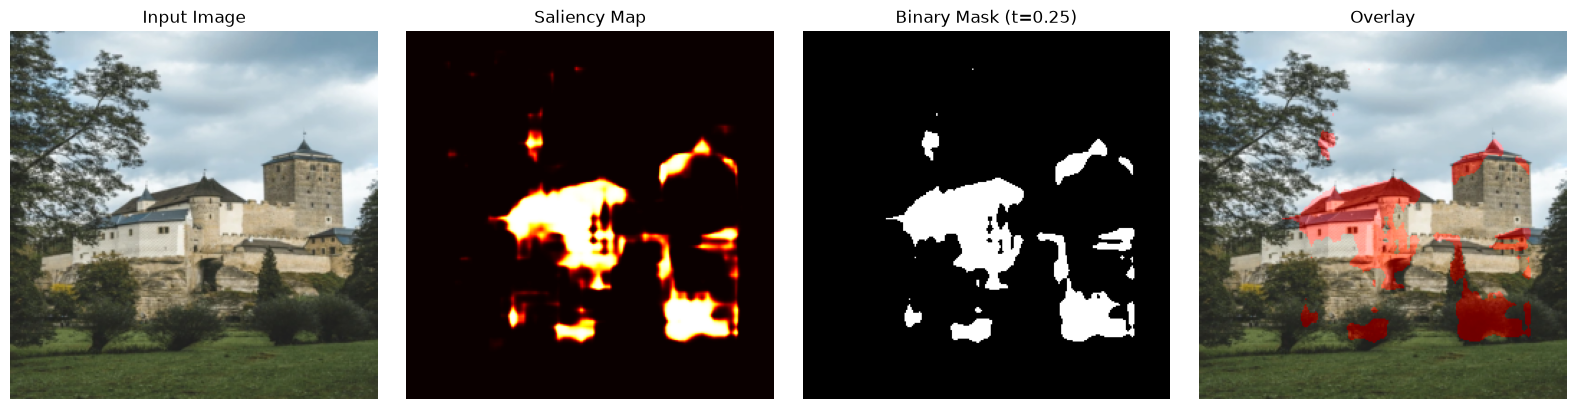

array([[0.00038991, 0.00038991, 0.00032475, ..., 0.00059045, 0.00108101,
        0.00108101],
       [0.00038991, 0.00038991, 0.00032475, ..., 0.00059045, 0.00108101,
        0.00108101],
       [0.00027716, 0.00027716, 0.00023037, ..., 0.00039929, 0.00075104,
        0.00075104],
       ...,
       [0.00030823, 0.00030823, 0.00022054, ..., 0.00234743, 0.00376148,
        0.00376148],
       [0.00043282, 0.00043282, 0.0003079 , ..., 0.00287067, 0.00453173,
        0.00453173],
       [0.00043282, 0.00043282, 0.0003079 , ..., 0.00287067, 0.00453173,
        0.00453173]], shape=(256, 256), dtype=float32)

In [31]:
run_inference(
    image_path="./medieval-castle.jpg",
    checkpoint_path="../checkpoints/best.pth",
    threshold=0.25,
    device="cuda",
    save_path="./saliency.png"
)